# 01 · End to end: one request through every layer

Phase 0 proved the stack runs. This notebook shows **where the time goes** when a request travels through it, first for single requests and then for a real multi-step agent task.

All numbers are read from `results/01_end_to_end/`.

## Where each number is measured

```
client ──► gateway ──► NGINX ──► vLLM API server ──► engine: queue → prefill → decode
  │           │           │              │                         │
  │           │           │              │                         └ vLLM /metrics (before/after snapshot)
  │           │           │              └ NGINX upstream time minus vLLM end to end
  │           │           └ NGINX access log (rt, urt)
  │           └ gateway JSON log (ttfb_ms, total_ms)
  └ client clock (TTFT, end to end)
```

vLLM only exposes totals, not per-request numbers. Sending one request at a time and snapshotting `/metrics` before and after gives that single request's exact queue, prefill and decode times (`loadtest/vllm_metrics.py`).

Each layer's share is the difference between nested timers: for example, **gateway** = gateway total − NGINX total. Clock resolution (NGINX logs to the millisecond) means very small layers can come out at ±1 ms.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "loadtest"))
from results_logger import load_runs, summarize

runs = load_runs("01_end_to_end")
traces = [r for r in runs if r["name"] == "trace_single_requests"]
agent_runs = [r for r in runs if r["name"] == "agent_run"]
print(f"{len(traces)} trace run(s), {len(agent_runs)} agent run(s)")
if runs:
    env = runs[-1]["environment"]
    gpu = env["gpus"][0] if env["gpus"] else {"name": "no GPU", "memory_mib": 0}
    print(f"hardware: {gpu['name']} ({gpu['memory_mib'] / 1024:.0f} GB) | model: {runs[-1]['config'].get('model')} "
          f"| vLLM: {runs[-1]['config'].get('vllm_image')} | config: {runs[-1]['config'].get('vllm_config')}")

1 trace run(s), 3 agent run(s)
hardware: NVIDIA GeForce RTX 5090 (32 GB) | model: Qwen/Qwen2.5-7B-Instruct | vLLM: vllm/vllm-openai:v0.30.0 | config: baseline


## Single requests, layer by layer

Three prompts from `loadtest/prompts.json`, each sent 5 times with nothing else running:

* **short_qa_05**: short question, short answer
* **summarize_01**: ~550 token document, medium answer (prefill heavy)
* **long_gen_02**: short prompt, long answer (decode heavy)

In [2]:
LAYERS = [
    ("client_to_gateway_s", "client ↔ gateway"),
    ("gateway_s", "gateway"),
    ("nginx_s", "NGINX"),
    ("vllm_api_server_s", "vLLM API server"),
    ("engine_queue_s", "engine: queue"),
    ("engine_prefill_s", "engine: prefill"),
    ("engine_decode_s", "engine: decode"),
    ("engine_other_s", "engine: other"),
]

if not traces:
    print("No trace runs yet: run scripts/run_phase1.sh on the GPU box, then copy results/ back.")
else:
    trace = traces[-1]
    samples = trace["metrics"]["samples"]
    prompt_ids = list(trace["metrics"]["summary"])

    print(f"{'median per request':<20}" + "".join(f"{p:>16}" for p in prompt_ids))
    for key in ["prompt_tokens", "output_tokens"]:
        print(f"{key.replace('_', ' '):<20}" + "".join(
            f"{summarize([s['client'][key] for s in samples if s['prompt_id'] == p])['p50']:>16}" for p in prompt_ids))
    for key, label in [("ttft_s", "TTFT"), ("e2e_s", "end to end")]:
        print(f"{label:<20}" + "".join(
            f"{trace['metrics']['summary'][p][key]['p50'] * 1000:>13.0f} ms" for p in prompt_ids))
    print()
    for key, label in LAYERS:
        values = [trace["metrics"]["summary"][p]["layers_p50_s"][key] for p in prompt_ids]
        print(f"{label:<20}" + "".join(f"{v * 1000:>13.1f} ms" if v is not None else f"{'n/a':>16}" for v in values))

median per request       short_qa_05    summarize_01     long_gen_02
prompt tokens                     32             477              45
output tokens                     64             172             768
TTFT                           16 ms           17 ms           16 ms
end to end                    618 ms         1651 ms         7347 ms

client ↔ gateway              1.0 ms          1.0 ms          1.0 ms
gateway                       1.0 ms          1.1 ms          0.6 ms
NGINX                         0.0 ms          0.0 ms          0.0 ms
vLLM API server               0.7 ms          0.8 ms          1.2 ms
engine: queue                 0.0 ms          0.0 ms          0.0 ms
engine: prefill              12.3 ms         12.5 ms         12.2 ms
engine: decode              601.6 ms       1633.7 ms       7330.5 ms
engine: other                 1.4 ms          2.1 ms          1.6 ms


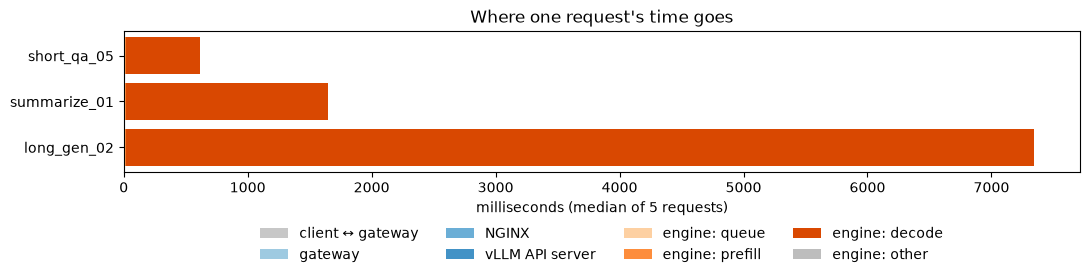

In [3]:
if traces:
    fig, ax = plt.subplots(figsize=(11, 3.2))
    colors = ["#c7c7c7", "#9ecae1", "#6baed6", "#4292c6", "#fdd0a2", "#fd8d3c", "#d94801", "#bdbdbd"]
    for row, p in enumerate(prompt_ids):
        left = 0.0
        for (key, label), color in zip(LAYERS, colors):
            value = max(trace["metrics"]["summary"][p]["layers_p50_s"][key] or 0.0, 0.0) * 1000
            ax.barh(row, value, left=left, color=color, label=label if row == 0 else None)
            left += value
    ax.set_yticks(range(len(prompt_ids)), prompt_ids)
    ax.invert_yaxis()
    ax.set_xlabel("milliseconds (median of 5 requests)")
    ax.set_title("Where one request's time goes")
    ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.3), frameon=False)
    plt.tight_layout()
    plt.show()

### Prefill vs decode, and what the prefix cache does

Each prompt was sent 5 times. The **first** request computes the whole prompt (cold). The **repeats** find the prompt already in vLLM's prefix cache and skip most of the prefill, so the medians above show cached prefill. This table separates the two.

vLLM's "prefill time" runs until the first output token exists, so it always includes one forward pass (~10 ms) even when almost nothing is left to compute.

In [4]:
if traces:
    print(f"{'':<14}{'prompt':>7}{'cached':>8}{'prefill (cold)':>16}{'prefill (cached)':>18}{'TTFT cold / cached':>21}{'ms per output token':>21}")
    for p in prompt_ids:
        rows = [s for s in samples if s["prompt_id"] == p]
        cold, warm = rows[0], rows[1:]
        warm_prefill = summarize([s["engine"]["prefill_s"] for s in warm])["p50"]
        warm_ttft = summarize([s["client"]["ttft_s"] for s in warm])["p50"]
        decode_ms = summarize([s["engine"]["decode_s"] / (s["client"]["output_tokens"] - 1) for s in rows])["p50"] * 1000
        print(f"{p:<14}{cold['client']['prompt_tokens']:>7}{warm[0]['engine']['prefix_cache_hits']:>8.0f}"
              f"{cold['engine']['prefill_s'] * 1000:>13.1f} ms{warm_prefill * 1000:>15.1f} ms"
              f"{cold['client']['ttft_s'] * 1000:>11.1f} / {warm_ttft * 1000:.1f} ms{decode_ms:>18.2f} ms")

               prompt  cached  prefill (cold)  prefill (cached)   TTFT cold / cached  ms per output token
short_qa_05        32      16         11.3 ms           12.3 ms       14.1 / 16.3 ms              9.55 ms
summarize_01      477     464         32.9 ms           12.5 ms       39.0 / 17.1 ms              9.55 ms
long_gen_02        45      32         12.0 ms           12.2 ms       16.1 / 16.4 ms              9.56 ms


## The agent: one task, several LLM calls

The CrewAI crew in `agent/app.py` summarizes an incident report with three agents in sequence (analyst → writer → reviewer). Every LLM call carries the same `x-run-id`, so the gateway and NGINX logs can be grouped by run.

In [5]:
if not agent_runs:
    print("No agent runs yet.")
else:
    print(f"{'run':<26}{'total':>9}{'LLM calls':>11}{'prompt tok':>12}{'gen tok':>9}{'prefill':>10}{'decode':>10}")
    for r in agent_runs:
        m, e = r["metrics"], r["metrics"]["engine"]
        print(f"{m['run_id']:<26}{m['total_s']:>8.1f}s{m['llm_calls']:>11}{e['prompt_tokens']:>12.0f}"
              f"{e['generation_tokens']:>9.0f}{e['prefill_s']:>9.2f}s{e['decode_s']:>9.2f}s")

run                           total  LLM calls  prompt tok  gen tok   prefill    decode
agent-20261004T015743Z         8.2s          3        1852      805     0.13s     7.67s
agent-20261004T015758Z         8.1s          3        1852      805     0.04s     7.67s
agent-20261004T015813Z         8.0s          3        1852      805     0.04s     7.67s


In [6]:
if agent_runs:
    run = agent_runs[-1]["metrics"]
    print(f"Latest run {run['run_id']}: {run['total_s']:.1f} s\n")
    print("Per task (CrewAI's view):")
    for t in run["tasks"]:
        print(f"  {t['agent']:<22}{t['duration_s']:>7.1f} s")
    print("\nPer LLM call (gateway and NGINX logs):")
    print(f"  {'#':<3}{'gateway total':>15}{'NGINX total':>13}{'vLLM (upstream)':>17}")
    for i, c in enumerate(run["calls"], 1):
        fmt = lambda v: f"{v:.2f} s" if v is not None else "n/a"
        print(f"  {i:<3}{fmt(c.get('gateway_total_s')):>15}{fmt(c.get('nginx_total_s')):>13}{fmt(c.get('upstream_total_s')):>17}")

    in_llm = sum(c.get("gateway_total_s") or 0 for c in run["calls"])
    e = run["engine"]
    print(f"\nTime waiting on the LLM: {in_llm:.1f} s of {run['total_s']:.1f} s ({in_llm / run['total_s']:.0%})")
    print(f"Agent framework overhead (everything else): {run['total_s'] - in_llm:.2f} s")
    print(f"Inside vLLM: prefill {e['prefill_s']:.2f} s, decode {e['decode_s']:.2f} s, queue {e['queue_s'] * 1000:.0f} ms")

Latest run agent-20261004T015813Z: 8.0 s

Per task (CrewAI's view):
  Incident analyst          4.3 s
  Technical writer          1.5 s
  Reviewer                  2.2 s

Per LLM call (gateway and NGINX logs):
  #    gateway total  NGINX total  vLLM (upstream)
  1           4.08 s       4.08 s           4.08 s
  2           1.47 s       1.47 s           1.47 s
  3           2.17 s       2.17 s           2.17 s

Time waiting on the LLM: 7.7 s of 8.0 s (96%)
Agent framework overhead (everything else): 0.33 s
Inside vLLM: prefill 0.04 s, decode 7.67 s, queue 0 ms


In [7]:
if agent_runs:
    print(agent_runs[-1]["metrics"]["final_summary"])

On 09:12 UTC, elevated error rates were observed in the Payments API. The root cause was a recent deployment of the fraud-scoring service, which introduced a synchronous call to an external risk provider within a database transaction. This led to database connection exhaustion, causing checkout failures. Approximately 11% of checkout attempts (4,100 customers) failed over a 32-minute window. The issue was resolved by rolling back the deployment at 09:38, and error rates normalized by 09:44. The on-call engineer was paged at 09:15, joined the incident channel at 09:19, and a second engineer noticed the deployment at 09:31. Moving the external call outside transactions, adding a 800-millisecond timeout with a fallback score, enhancing alerts on connection pool utilization above 80%, and requiring load tests for any change involving network calls are planned changes. Additionally, the deployment pipeline lacked automated canary analysis, allowing the regression to affect all traffic withi

## Grafana

The dashboard (`observability/grafana/dashboards/llm_inference.json`) is provisioned automatically. These screenshots cover the Phase 1 session: the traces around 21:57, the agent runs right after, and extra agent runs around 22:01 once the GPU exporter was fixed (see below).

![Overview](images/01_end_to_end/grafana_1_overview.png)

![Latency](images/01_end_to_end/grafana_2_latency.png)

![Traffic](images/01_end_to_end/grafana_3_traffic.png)

![Engine capacity](images/01_end_to_end/grafana_4_engine_capacity.png)

![GPU](images/01_end_to_end/grafana_5_gpu.png)

Things to read from them:

* **GPU memory** sits at ~28 GiB once vLLM reserves 90% of the card, and **GPU utilization hits 100% at ~470 W** while generating.
* **KV cache usage stays near 0%**: one request at a time barely touches the 209k token cache. Phase 4 fills it.
* **Prefix cache hit rate climbs to ~98%** as the agent resends the same prompts.
* **The 502 errors around 21:55** are the setup script polling `/v1/models` while vLLM was still loading the model. All 27 chat completions returned 200.
* **The gap in the GPU panels (~21:55 to 22:00)**: installing `python3-venv` on the host triggered a systemd reload, and the exporter's container lost access to the GPU (`Failed to initialize NVML: Unknown Error`). vLLM already had the GPU open and was unaffected. Restarting the exporter fixed it, and `setup_gpu_box.sh` now installs packages before any container starts.
* **Dashboard percentiles are estimates.** Prometheus computes them from histogram buckets, so the inter token latency panel shows ~5.5 ms at p50 when the exact per-request measurement is 9.55 ms. The traced numbers in this notebook are the precise ones; the dashboard is for spotting trends live.

## What happened

**1. Almost all the time is the GPU generating tokens.** For a single request, decode is 97% (short answer) to 99.8% (768 token answer) of end to end time. Everything outside the engine (client, gateway, NGINX, vLLM's HTTP layer) adds up to **under 3 ms**. The gateway, NGINX and HTTP plumbing cost effectively nothing at this load.

**2. Decode speed is constant: 9.55 ms per output token (~105 tokens/s), whatever the prompt.** So end to end latency is roughly `TTFT + 9.55 ms × output tokens`: 64 tokens took 0.62 s, 172 took 1.65 s, 768 took 7.35 s. For a 7B model on one GPU, the length of the answer, not the question, decides how long a request takes.

**3. Prefill is fast, and the prefix cache makes it faster.** The 477 token document prefilled in 33 ms cold (TTFT 39 ms) and 12.5 ms once cached (TTFT 17 ms).

**4. Phase 0's 281 ms TTFT was a cold start.** A warmed up server answers in 14 to 17 ms. The very first request after startup pays one time costs, so benchmarks need a warmup request (the tracer sends one).

**5. The agent is 96% waiting on the LLM.** One crew run takes ~8.1 s for 3 LLM calls (analyst 4.3 s, writer 1.5 s, reviewer 2.2 s), and only ~0.34 s of that is CrewAI itself. 805 generated tokens × 9.55 ms ≈ 7.7 s, which is the run. On repeat runs, 98.5% of the 1,852 prompt tokens came from the prefix cache, cutting total prefill from 125 ms to 38 ms. That saving is small next to decode, which is the real cost.

**What this means for later phases:** with one request at a time, the GPU is fast but underused: KV cache stays near 0% and the batch holds one sequence. The next questions are what happens when many users share it (Phase 4), and how much throughput batching unlocks before latency degrades.

## Phase 1 exit criteria

- [x] CrewAI agent making several LLM calls through the gateway, tagged with a run ID
- [x] Request IDs and run IDs logged at the gateway and NGINX
- [x] GPU metrics exporter and a provisioned Grafana dashboard
- [x] Layer-by-layer tracing of single requests, saved to `results/01_end_to_end/`
- [x] Phase 1 session on the RTX 5090: traces, agent runs and dashboard captured
- [x] One request fully explained with per-layer timings